# Food Demand Forecasting

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import preprocessing


In [2]:
models=[]
rmsle_li=[]

In [3]:
# Read training and test datasets.
df_train = pd.read_csv('train.csv')
df_center_info = pd.read_csv('fulfilment_center_info.csv')
df_meal_info = pd.read_csv('meal_info.csv')
df_test = pd.read_csv('test_QoiMO9B.csv')

In [4]:
print("Total number of centers : ", df_center_info['center_id'].nunique())

Total number of centers :  77


In [5]:
print("Types of centers : \n")
print(df_center_info['center_type'].unique())


Types of centers : 

['TYPE_A' 'TYPE_B' 'TYPE_C']


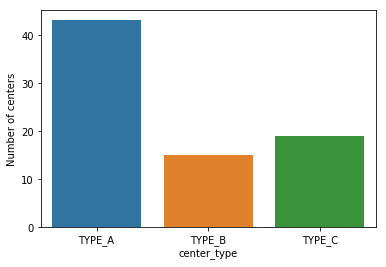

In [6]:
ax = sns.countplot(df_center_info['center_type'])
ax.set(ylabel='Number of centers')
plt.show()

In [7]:
print("Total Number of cities: ", df_center_info['city_code'].nunique())
print("Total number of regions: ", df_center_info['region_code'].nunique())

Total Number of cities:  51
Total number of regions:  8


In [8]:
print("Total number of different types of meal: ", df_meal_info['meal_id'].nunique())

Total number of different types of meal:  51


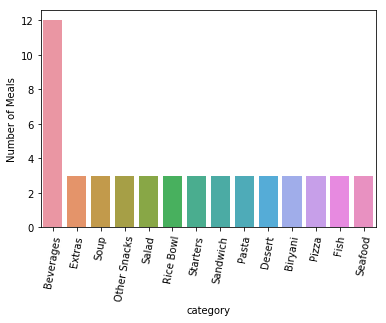

In [9]:
ax = sns.countplot(df_meal_info['category'])
ax.set(ylabel= "Number of Meals")
plt.xticks(rotation=80)
plt.show()

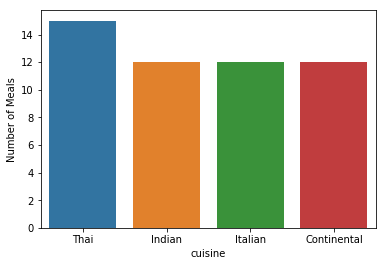

In [10]:
ax = sns.countplot(df_meal_info['cuisine'])
ax.set(ylabel= "Number of Meals")
plt.show()

In [11]:
# Merge the training data with the branch and meal information.
df_train = pd.merge(df_train, df_center_info,
                    how="left",
                    left_on='center_id',
                    right_on='center_id')

df_train = pd.merge(df_train, df_meal_info,
                    how='left',
                    left_on='meal_id',
                    right_on='meal_id')

In [12]:
# Merge the test data with the branch and meal information.
df_test = pd.merge(df_test, df_center_info,
                   how="left",
                   left_on='center_id',
                   right_on='center_id')

df_test = pd.merge(df_test, df_meal_info,
                   how='left',
                   left_on='meal_id',
                   right_on='meal_id')

In [13]:
# Convert 'city_code' and 'region_code' into a single feature - 'city_region'.
df_train['city_region'] = \
        df_train['city_code'].astype('str') + '_' + \
        df_train['region_code'].astype('str')

df_test['city_region'] = \
        df_test['city_code'].astype('str') + '_' + \
        df_test['region_code'].astype('str')

In [14]:
# Label encode categorical columns for use in LightGBM.
label_encode_columns = ['center_id', 
                        'meal_id', 
                        'city_code', 
                        'region_code', 
                        'city_region', 
                        'center_type', 
                        'category', 
                        'cuisine']

le = preprocessing.LabelEncoder()

In [15]:
for col in label_encode_columns:
    le.fit(df_train[col])
    df_train[col + '_encoded'] = le.transform(df_train[col])
    df_test[col + '_encoded'] = le.transform(df_test[col])

In [16]:
df_train.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,...,cuisine,city_region,center_id_encoded,meal_id_encoded,city_code_encoded,region_code_encoded,city_region_encoded,center_type_encoded,category_encoded,cuisine_encoded
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,...,Thai,647_56,23,22,30,3,30,2,0,3
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,...,Thai,647_56,23,26,30,3,30,2,0,3
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,...,Thai,647_56,23,38,30,3,30,2,0,3
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,...,Indian,647_56,23,29,30,3,30,2,0,1
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,...,Indian,647_56,23,42,30,3,30,2,0,1


In [17]:
# Feature engineering - treat 'week' as a cyclic feature.
# Encode it using sine and cosine transform.
df_train['week_sin'] = \
        np.sin(2 * np.pi * df_train['week'] / 52.143)
df_train['week_cos'] = \
        np.cos(2 * np.pi * df_train['week'] / 52.143)

df_test['week_sin'] = \
        np.sin(2 * np.pi * df_test['week'] / 52.143)
df_test['week_cos'] = \
        np.cos(2 * np.pi * df_test['week'] / 52.143)


In [18]:
# Feature engineering - percent difference between base price and checkout price.
df_train['price_diff_percent'] = \
        (df_train['base_price'] - df_train['checkout_price']) / \
        df_train['base_price']


df_test['price_diff_percent'] = \
        (df_test['base_price'] - df_test['checkout_price']) / \
        df_test['base_price']


In [19]:
# Convert email and homepage features into a single feature - 'email_plus_homepage'.
df_train['email_plus_homepage'] = \
        df_train['emailer_for_promotion'] + \
        df_train['homepage_featured']

df_test['email_plus_homepage'] = \
        df_test['emailer_for_promotion'] + \
        df_test['homepage_featured']


In [20]:
# Prepare a list of columns to train on.
# Also decide which features to treat as numeric and which features to treat
# as categorical.
columns_to_train = ['week',
                    'week_sin',
                    'week_cos',
                    'checkout_price',
                    'base_price',
                    'price_diff_percent',
                    'email_plus_homepage',
                    'city_region_encoded',
                    'center_type_encoded',
                    'op_area',
                    'category_encoded',
                    'cuisine_encoded',
                    'center_id_encoded',
                    'meal_id_encoded']

categorical_columns = ['email_plus_homepage',
                       'city_region_encoded',
                       'center_type_encoded',
                       'category_encoded',
                       'cuisine_encoded',
                       'center_id_encoded',
                       'meal_id_encoded']
numerical_columns = [col for col in columns_to_train if col not in categorical_columns]

In [21]:
# Log transform the target variable - num_orders.
df_train['num_orders_log1p'] = np.log1p(df_train['num_orders'])

In [22]:
X = df_train[categorical_columns + numerical_columns]
y = df_train['num_orders_log1p']
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    shuffle=False)

# Linear Regression

In [23]:
# Fitting Simple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression() #baseline model
regressor.fit(X_train, y_train)


LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [24]:
X_train.shape

(342411, 14)

In [25]:
b1,b2,b3,b4,b5,b6,b7,b8,b9,b10,b11,b12,b13,b14 = regressor.coef_
#coefficient is an array with values for each column.
#y = bo + b1x1 + b2x2....
b0 = regressor.intercept_

In [26]:
# Predicting the Test set results
y_pred_lr = regressor.predict(X_test)
y_pred_lr

array([4.40222245, 3.49639437, 5.74459541, ..., 5.30095513, 5.30876939,
       5.33192155])

In [27]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, mean_squared_log_error
msle = mean_squared_log_error(y_test,y_pred_lr)
rmsle = msle**0.5
print('RMSLE: ',rmsle)
#RMSE and MAE should be close as MAE is on actual value and RMSE is square then root so in a way actual value
rmsle_li.append(rmsle)
models.append('Linear Regression')

RMSLE:  0.17556550298702597


# BAYESIAN RIDGE LINEAR MODEL

In [28]:
# Fitting Simple Linear Regression to the Training set
from sklearn.linear_model import BayesianRidge
bayesianRidge = BayesianRidge() #baseline model
bayesianRidge.fit(X_train, y_train)

BayesianRidge(alpha_1=1e-06, alpha_2=1e-06, compute_score=False, copy_X=True,
       fit_intercept=True, lambda_1=1e-06, lambda_2=1e-06, n_iter=300,
       normalize=False, tol=0.001, verbose=False)

In [29]:
y_pred_br = bayesianRidge.predict(X_test)
y_pred_br

array([4.40239009, 3.49664163, 5.7450569 , ..., 5.3015818 , 5.30932485,
       5.33183711])

In [30]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, mean_squared_log_error
msle = mean_squared_log_error(y_test,y_pred_br)
rmsle = msle**0.5
print('RMSLE: ',rmsle)
#RMSE and MAE should be close as MAE is on actual value and RMSE is square then root so in a way actual value
rmsle_li.append(rmsle)
models.append('Bayesian Ridge')

RMSLE:  0.17556714567035642


# ElasticNet

In [31]:
from sklearn.linear_model import ElasticNet
elasticnet =ElasticNet() #baseline model
elasticnet.fit(X_train, y_train)

ElasticNet(alpha=1.0, copy_X=True, fit_intercept=True, l1_ratio=0.5,
      max_iter=1000, normalize=False, positive=False, precompute=False,
      random_state=None, selection='cyclic', tol=0.0001, warm_start=False)

In [32]:
y_pred_en = elasticnet.predict(X_test)
y_pred_en

array([4.9178302 , 4.14171848, 5.33671773, ..., 5.4548593 , 5.39868298,
       5.04306909])

In [33]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, mean_squared_log_error
msle = mean_squared_log_error(y_test,y_pred_en)
rmsle = msle**0.5
print('RMSLE: ',rmsle)
#RMSE and MAE should be close as MAE is on actual value and RMSE is square then root so in a way actual value
rmsle_li.append(rmsle)
models.append('Elastic Net')

RMSLE:  0.19338339195555782


# Lasso

In [34]:
from sklearn.linear_model import Lasso
lasso = Lasso() #baseline model
lasso.fit(X_train, y_train)

Lasso(alpha=1.0, copy_X=True, fit_intercept=True, max_iter=1000,
   normalize=False, positive=False, precompute=False, random_state=None,
   selection='cyclic', tol=0.0001, warm_start=False)

In [35]:
y_pred_la = lasso.predict(X_test)
y_pred_la

array([4.9179373 , 4.1903861 , 5.24254916, ..., 5.34177236, 5.29092365,
       4.96648164])

In [36]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, mean_squared_log_error
msle = mean_squared_log_error(y_test,y_pred_la)
rmsle = msle**0.5
print('RMSLE: ',rmsle)
#RMSE and MAE should be close as MAE is on actual value and RMSE is square then root so in a way actual value
rmsle_li.append(rmsle)
models.append('Lasso')

RMSLE:  0.19561215822406244


# Ridge

In [37]:
from sklearn.linear_model import Ridge
ridge =Ridge() #baseline model
ridge.fit(X_train, y_train)

Ridge(alpha=1.0, copy_X=True, fit_intercept=True, max_iter=None,
   normalize=False, random_state=None, solver='auto', tol=0.001)

In [38]:
y_pred_rd = ridge.predict(X_test)


In [39]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, mean_squared_log_error
msle = mean_squared_log_error(y_test,y_pred_rd)
rmsle = msle**0.5
print('RMSLE: ',rmsle)
#RMSE and MAE should be close as MAE is on actual value and RMSE is square then root so in a way actual value
rmsle_li.append(rmsle)
models.append('Ridge')

RMSLE:  0.17556588588554037


# Decision Tree Regressor

In [40]:
from sklearn.tree import DecisionTreeRegressor
dtr =DecisionTreeRegressor() #baseline model
dtr.fit(X_train, y_train)

DecisionTreeRegressor(criterion='mse', max_depth=None, max_features=None,
           max_leaf_nodes=None, min_impurity_decrease=0.0,
           min_impurity_split=None, min_samples_leaf=1,
           min_samples_split=2, min_weight_fraction_leaf=0.0,
           presort=False, random_state=None, splitter='best')

In [41]:
y_pred_dtr = dtr.predict(X_test)
y_pred_dtr

array([2.77258872, 4.00733319, 6.26909628, ..., 6.74758653, 6.88038408,
       6.29341928])

In [42]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, mean_squared_log_error
msle = mean_squared_log_error(y_test,y_pred_dtr)
rmsle = msle**0.5
print('RMSLE: ',rmsle)
#RMSE and MAE should be close as MAE is on actual value and RMSE is square then root so in a way actual value
rmsle_li.append(rmsle)
models.append('Decision Tree Regressor')

RMSLE:  0.1608948241150566


# Random Forest Regressor

In [43]:
from sklearn.ensemble import RandomForestRegressor
rf =RandomForestRegressor() #baseline model
rf.fit(X_train, y_train)

C:\Users\MUJ\Anaconda3\lib\site-packages\sklearn\ensemble\forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=None,
           oob_score=False, random_state=None, verbose=0, warm_start=False)

In [44]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([3.78042849, 3.95453992, 6.26364416, ..., 6.37420426, 6.36529125,
       5.56110412])

In [45]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, mean_squared_log_error
msle = mean_squared_log_error(y_test,y_pred_rf)
rmsle = msle**0.5
print('RMSLE: ',rmsle)
#RMSE and MAE should be close as MAE is on actual value and RMSE is square then root so in a way actual value
rmsle_li.append(rmsle)
models.append('Random Forest Regressor')

RMSLE:  0.11754998312244812


In [46]:
models

['Linear Regression',
 'Bayesian Ridge',
 'Elastic Net',
 'Lasso',
 'Ridge',
 'Decision Tree Regressor',
 'Random Forest Regressor']

In [47]:
model_dict = {'Models': models,
              'RMSLE': rmsle_li
             }
model_dict

{'Models': ['Linear Regression',
  'Bayesian Ridge',
  'Elastic Net',
  'Lasso',
  'Ridge',
  'Decision Tree Regressor',
  'Random Forest Regressor'],
 'RMSLE': [0.17556550298702597,
  0.17556714567035642,
  0.19338339195555782,
  0.19561215822406244,
  0.17556588588554037,
  0.1608948241150566,
  0.11754998312244812]}

In [48]:
model_df = pd.DataFrame(model_dict)
model_df

,Models,RMSLE
0,Linear Regression,0.175566
1,Bayesian Ridge,0.175567
2,Elastic Net,0.193383
3,Lasso,0.195612
4,Ridge,0.175566
5,Decision Tree Regressor,0.160895
6,Random Forest Regressor,0.117550


In [49]:
model_df = model_df.sort_values(['RMSLE'])
model_df

,Models,RMSLE
6,Random Forest Regressor,0.117550
5,Decision Tree Regressor,0.160895
0,Linear Regression,0.175566
4,Ridge,0.175566
1,Bayesian Ridge,0.175567
2,Elastic Net,0.193383
3,Lasso,0.195612


In [50]:
best_model = model_df['Models'].values[0]
best_model

'Random Forest Regressor'

In [51]:
from sklearn.metrics import make_scorer
def rmsle_func(y_test, y_pred):
    msle = mean_squared_log_error(y_test,y_pred)
    rmsle=msle**0.5
    return rmsle

In [52]:
rmsle_scorer = make_scorer(rmsle_func,greater_is_better=False)

In [54]:
# Applying Grid Search to find the best model and the best parameters
from sklearn.model_selection import GridSearchCV
parameters = {"n_estimators": [200,300],
              "criterion":['mse'],
              "max_depth": [4,9,13],
              "min_samples_split": [7,10,20],
              "min_samples_leaf": [3,5,7],
              "min_weight_fraction_leaf": [0.05,0.025]
              }

grid_search = GridSearchCV(estimator = rf,
                           param_grid = parameters,
                           scoring = rmsle_scorer,
                           cv = 10,
                           n_jobs = -1)
grid_search = grid_search.fit(X_train, y_train)

In [55]:
best_parameters = grid_search.best_params_
best_parameters

{'criterion': 'mse',
 'max_depth': 9,
 'min_samples_leaf': 3,
 'min_samples_split': 7,
 'min_weight_fraction_leaf': 0.025,
 'n_estimators': 300}

In [56]:
from sklearn.ensemble import RandomForestRegressor
tunedRF = RandomForestRegressor(n_estimators = best_parameters["n_estimators"],
                                 criterion = best_parameters["criterion"],
                                 max_depth = best_parameters["max_depth"],
                                 min_samples_split = best_parameters["min_samples_split"],
                                 min_samples_leaf = best_parameters["min_samples_leaf"],
                                 min_weight_fraction_leaf = best_parameters["min_weight_fraction_leaf"])
tunedRF.fit(X_train, y_train)

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=9,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=3, min_samples_split=7,
           min_weight_fraction_leaf=0.025, n_estimators=300, n_jobs=None,
           oob_score=False, random_state=None, verbose=0, warm_start=False)

In [57]:
msle = mean_squared_log_error(y_test,tunedRF.predict(X_test))
rmsle = msle**0.5
print('RMSLE for Tuned RF: \n',rmsle)


RMSLE for Tuned RF: 
 0.14541788210254197


In [58]:
df_test.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,city_code,region_code,...,city_code_encoded,region_code_encoded,city_region_encoded,center_type_encoded,category_encoded,cuisine_encoded,week_sin,week_cos,price_diff_percent,email_plus_homepage
0,1028232,146,55,1885,158.11,159.11,0,0,647,56,...,30,3,30,2,0,3,-0.951071,0.308971,0.006285,0
1,1127204,146,55,1993,160.11,159.11,0,0,647,56,...,30,3,30,2,0,3,-0.951071,0.308971,-0.006285,0
2,1212707,146,55,2539,157.14,159.14,0,0,647,56,...,30,3,30,2,0,3,-0.951071,0.308971,0.012568,0
3,1082698,146,55,2631,162.02,162.02,0,0,647,56,...,30,3,30,2,0,1,-0.951071,0.308971,0.000000,0
4,1400926,146,55,1248,163.93,163.93,0,0,647,56,...,30,3,30,2,0,1,-0.951071,0.308971,0.000000,0


In [59]:
X = df_test[categorical_columns + numerical_columns]

pred = tunedRF.predict(X)
pred = np.expm1(pred)

submission_df = df_test.copy()
submission_df['num_orders'] = pred
submission_df = submission_df[['id', 'num_orders']]
submission_df.to_csv('submission.csv', index=False)